# UZCARD-XL — процессинг платежей (Трек A)

**UZCARD Academy · Mini-project: Data analysis · 2026**

| Участник | Гипотеза |
|---|---|
| **Ибрахимжон Тожибоев** | A1 — Портфель и динамика: где растём |
| **Участник 2** *(имя)* | A2 — Отказы: сегмент «студенты» теряет каждую 9-ю операцию |
| **Участник 3** *(имя)* | A3 — Споры: 90 % спорных денег — в онлайне |

**Запрос заказчика (продуктовая и антифрод-команда UZCARD):» «Нужно понять, кто наши
клиенты и как они платят, где бизнес растёт и где проседает, и где мы теряем деньги
(отказы, спорные операции)».

**Главные выводы:** объём операций растёт ×16 за год (осознанный ramp-up портфеля,
декабрь +63 % — сезон); деньги теряются в двух местах: (1) сегмент **student** —
отказ на 11,2 % операций (вдвое выше остальных, драйвер — нехватка средств и лимиты),
(2) **онлайн-мерчанты** — 1,16 % операций оспаривается (в 10–20 раз выше офлайна),
это 90 % всех спорных сумм: 103 млн UZS.

## Таблицы трека A и связи

| Таблица | Строк | Ключи |
|---|---|---|
| `ds_customers` (2 000) | клиенты | `customer_id` |
| `ds_cards` (3 286) | карты | `card_id → customer_id` |
| `ds_transactions_2` (60 320) | операции 2023 г. | `card_id`, `merchant_id` |
| `ds_merchants_2` (600) | мерчанты | `merchant_id`, `mcc_code` |
| `ds_mcc_categories` (28) | справочник MCC | `mcc_code` |

Принадлежность проверена JOIN-ами: все 60 320 операций соединяются с картами и
мерчантами. `ds_disputes` треку A не принадлежит (её `txn_id` полностью совпадает
с `ds_transactions_1` трека C); признак спора у нас — флаг `is_disputed`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
from sqlalchemy import create_engine

# Ulanish: db_config.py dan o'qiladi (repoda yo'q - db_config.example.py dan nusxa oling)
import sys, pathlib
_p = pathlib.Path.cwd()
while not (_p/"db_config.py").exists() and _p != _p.parent: _p = _p.parent
sys.path.insert(0, str(_p))
from db_config import DB_URL
ENGINE = create_engine(DB_URL)
def q(sql): return pd.read_sql(sql, ENGINE)

BLUE, AQUA, YELLOW, GREEN, VIOLET = "#2a78d6", "#1baf7a", "#eda100", "#008300", "#4a3aa7"
CRITICAL, INK, INK2, MUTED, GRID, SURFACE = "#d03b3b", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "figure.dpi": 110,
    "axes.edgecolor": "#c3c2b7", "axes.linewidth": 0.8, "axes.grid": True,
    "grid.color": GRID, "grid.linewidth": 0.7, "axes.axisbelow": True,
    "text.color": INK, "axes.labelcolor": INK2, "xtick.color": MUTED, "ytick.color": MUTED,
    "font.family": "sans-serif", "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.spines.top": False, "axes.spines.right": False, "legend.frameon": False,
})
def save(fig, name): fig.savefig(f"../charts/{name}.png", bbox_inches="tight", facecolor=SURFACE)
print(q("SELECT current_database() db, current_user usr").iloc[0].to_dict())

{'db': 'academy_db', 'usr': 'itojiboyev'}


In [2]:
# Проверка связей своего трека
q("""
SELECT (SELECT count(*) FROM ds_transactions_2)                                    AS txns,
       (SELECT count(*) FROM ds_transactions_2 t JOIN ds_cards c USING(card_id))   AS join_cards,
       (SELECT count(*) FROM ds_transactions_2 t JOIN ds_merchants_2 m USING(merchant_id)) AS join_merchants,
       (SELECT count(*) FROM ds_cards c JOIN ds_customers cu USING(customer_id))   AS cards_customers
""")

,txns,join_cards,join_merchants,cards_customers
0,60320,60320,60320,3286


---
## Гипотеза A1 — Ибрахимжон Тожибоев
### Рост операций — это ramp-up портфеля, а декабрьский всплеск — сезонность

**A1:** объём операций растёт весь 2023 год за счёт постепенной активации портфеля
карт (выпускается с 2019 г.), а не разового события; декабрь — сезонный пик.

**Метод:** CTE + оконная `LAG` (MoM-рост), тренд по янв–ноя, 95 % ДИ темпа роста.

In [3]:
a1 = q("""
WITH monthly AS (
  SELECT date_trunc('month', txn_ts)::date AS month, count(*) AS txns,
         sum(amount_uzs)/1e9 AS volume_bln,
         count(DISTINCT card_id) AS active_cards
  FROM ds_transactions_2 GROUP BY 1
)
SELECT month, txns, volume_bln, active_cards,
       round(100.0*(txns - LAG(txns) OVER (ORDER BY month))/LAG(txns) OVER (ORDER BY month),1) AS mom_pct
FROM monthly ORDER BY month
""")
a1

,month,txns,volume_bln,active_cards,mom_pct
0,2023-01-01,769,0.165284,678,NaN
1,2023-02-01,1461,0.309083,1163,90.0
2,2023-03-01,2101,0.473745,1497,43.8
3,2023-04-01,2828,0.598051,1848,34.6
4,2023-05-01,3519,0.731795,2116,24.4
5,2023-06-01,4324,0.889802,2315,22.9
6,2023-07-01,5026,1.049642,2474,16.2
7,2023-08-01,5752,1.198889,2619,14.4
8,2023-09-01,6479,1.340543,2737,12.6
9,2023-10-01,7317,1.488093,2838,12.9


Тренд янв-ноя: +23.5%/мес (R²=0.914, p=4.3e-06)
Средний MoM янв-ноя: 27.9%, 95% ДИ [10.5; 45.4]
Декабрь: +63% MoM — сезонный пик


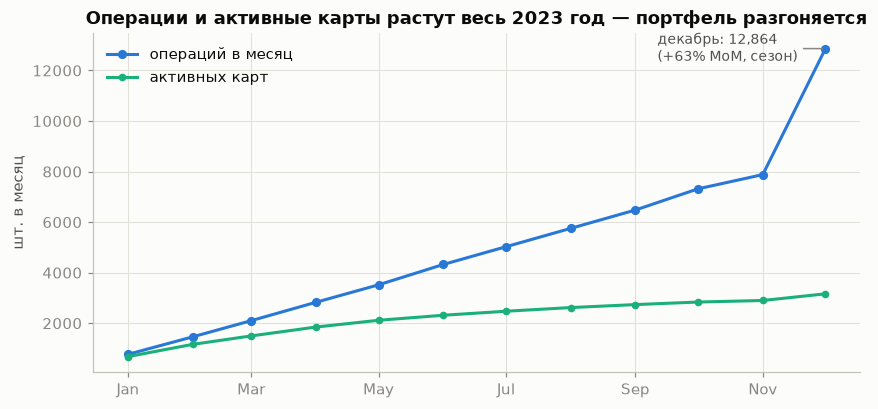

In [4]:
x = np.arange(11); y = np.log(a1["txns"].values[:11])
slope, intercept, r, p, se = stats.linregress(x, y)
g = a1["mom_pct"].dropna().values[:10]  # янв-ноя
ci = stats.t.interval(0.95, len(g)-1, loc=g.mean(), scale=stats.sem(g))
print(f"Тренд янв-ноя: +{(np.exp(slope)-1)*100:.1f}%/мес (R²={r**2:.3f}, p={p:.1e})")
print(f"Средний MoM янв-ноя: {g.mean():.1f}%, 95% ДИ [{ci[0]:.1f}; {ci[1]:.1f}]")
print(f"Декабрь: +{a1.mom_pct.iloc[11]:.0f}% MoM — сезонный пик")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(a1["month"], a1["txns"], color=BLUE, lw=2, marker="o", ms=5, label="операций в месяц")
ax.plot(a1["month"], a1["active_cards"], color=AQUA, lw=2, marker="o", ms=4, label="активных карт")
ax.annotate(f"декабрь: {a1.txns.iloc[11]:,}\n(+{a1.mom_pct.iloc[11]:.0f}% MoM, сезон)",
            xy=(a1.month.iloc[11], a1.txns.iloc[11]), xytext=(-110, -8), textcoords="offset points",
            fontsize=9, color=INK2, arrowprops=dict(arrowstyle="-", color=MUTED))
ax.set_title("Операции и активные карты растут весь 2023 год — портфель разгоняется")
ax.set_ylabel("шт. в месяц")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.legend(loc="upper left")
save(fig, "a1_growth"); plt.show()

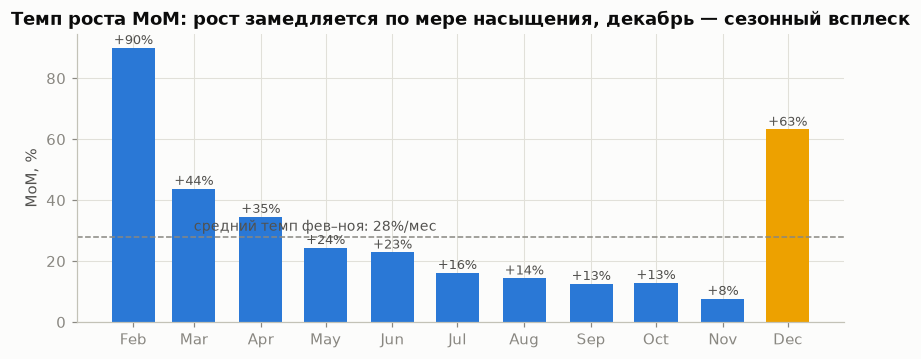

In [5]:
fig, ax = plt.subplots(figsize=(9, 3.4))
colors = [YELLOW if i == 11 else BLUE for i in range(1, len(a1))]
ax.bar(a1["month"][1:], a1["mom_pct"][1:], width=20, color=colors)
for xm, v in zip(a1["month"][1:], a1["mom_pct"][1:]):
    ax.text(xm, v + 1.2, f"{v:+.0f}%", ha="center", fontsize=8.5, color=INK2)
ax.axhline(g.mean(), color=MUTED, lw=1, ls="--")
ax.text(a1["month"].iloc[2], g.mean()+2, f"средний темп фев–ноя: {g.mean():.0f}%/мес", fontsize=9, color=INK2)
ax.set_title("Темп роста MoM: рост замедляется по мере насыщения, декабрь — сезонный всплеск")
ax.set_ylabel("MoM, %"); ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
save(fig, "a1_mom"); plt.show()

**Вывод A1.** Операции выросли с 769 (янв) до 12 864 (дек) — в 16 раз; активные карты
растут синхронно: это управляемый ramp-up портфеля (карты выпускаются с 2019 г.),
а не аномалия. Средний темп фев–ноя +23 %/мес с постепенным замедлением к ~4–6 %
(насыщение); декабрь **+63 % MoM** — сезонный пик покупок. Доля отказов при этом
стабильна (5,5–6,9 % без тренда) — рост нагрузки качество авторизации не ухудшил.

---

## Гипотеза A2 — Участник 2 *(имя)*
### Сегмент «student» теряет каждую девятую операцию

**A2:** доля отказов у студентов вдвое выше остальных сегментов, и причина —
не мошенничество, а нехватка средств/лимиты, т. е. продуктовая проблема.

**Метод:** JOIN операций → карты → клиенты, GROUP BY сегмент, **z-тест двух долей**
(student vs остальные) + 95 % ДИ, разбор причин отказов.

customer_segment  txns  declined  declined_pct
         student  2967       332          11.2
         premium  8973       531           5.9
            mass 31551      1831           5.8
         payroll 16829       984           5.8

student: 11.2% vs остальные: 5.8% | z = 11.9, p = 1.4e-32
Разница +5.4 п.п., 95% ДИ [4.2; 6.5]


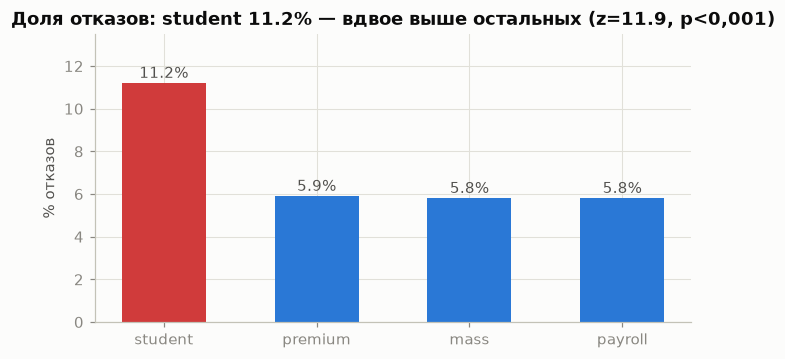

In [6]:
seg = q("""
SELECT cu.customer_segment,
       count(*) AS txns,
       count(*) FILTER (WHERE t.txn_status='declined') AS declined,
       round(100.0*count(*) FILTER (WHERE t.txn_status='declined')/count(*), 1) AS declined_pct
FROM ds_transactions_2 t
JOIN ds_cards c USING(card_id)
JOIN ds_customers cu USING(customer_id)
GROUP BY 1 ORDER BY declined_pct DESC
""")
d1 = int(seg.loc[seg.customer_segment=="student", "declined"].iloc[0]); n1 = int(seg.loc[seg.customer_segment=="student", "txns"].iloc[0])
d0 = int(seg.loc[seg.customer_segment!="student", "declined"].sum());   n0 = int(seg.loc[seg.customer_segment!="student", "txns"].sum())
p1, p0 = d1/n1, d0/n0
pp = (d1+d0)/(n1+n0)
z = (p1-p0)/np.sqrt(pp*(1-pp)*(1/n1+1/n0)); pv = 2*stats.norm.sf(abs(z))
se_d = np.sqrt(p1*(1-p1)/n1 + p0*(1-p0)/n0)
print(seg.to_string(index=False))
print(f"\nstudent: {p1:.1%} vs остальные: {p0:.1%} | z = {z:.1f}, p = {pv:.1e}")
print(f"Разница +{(p1-p0)*100:.1f} п.п., 95% ДИ [{(p1-p0-1.96*se_d)*100:.1f}; {(p1-p0+1.96*se_d)*100:.1f}]")

fig, ax = plt.subplots(figsize=(7, 3.4))
colors = [CRITICAL if s == "student" else BLUE for s in seg["customer_segment"]]
ax.bar(seg["customer_segment"], seg["declined_pct"], width=0.55, color=colors)
for i, r_ in seg.iterrows():
    ax.text(i, r_["declined_pct"]+0.25, f"{r_.declined_pct}%", ha="center", fontsize=10, color=INK2)
ax.set_title(f"Доля отказов: student {p1:.1%} — вдвое выше остальных (z={z:.1f}, p<0,001)")
ax.set_ylabel("% отказов"); ax.set_ylim(0, 13.5)
save(fig, "a2_segments"); plt.show()

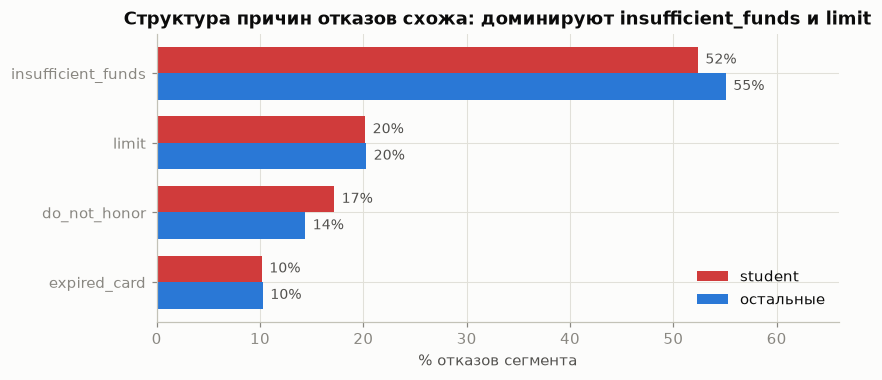

student: insufficient_funds + limit = 72.6 % отказов


In [7]:
# Причины отказов: студенты vs остальные (доли внутри сегмента)
rs = q("""
SELECT CASE WHEN cu.customer_segment='student' THEN 'student' ELSE 'остальные' END AS grp,
       t.decline_reason, count(*) AS n
FROM ds_transactions_2 t
JOIN ds_cards c USING(card_id) JOIN ds_customers cu USING(customer_id)
WHERE t.txn_status='declined'
GROUP BY 1, 2
""")
piv = rs.pivot(index="decline_reason", columns="grp", values="n")
piv = (100*piv/piv.sum()).round(1).sort_values("student", ascending=True)

fig, ax = plt.subplots(figsize=(8, 3.4))
ypos = np.arange(len(piv)); h = 0.38
ax.barh(ypos + h/2, piv["student"], h, color=CRITICAL, label="student")
ax.barh(ypos - h/2, piv["остальные"], h, color=BLUE, label="остальные")
for yv, (s_, o_) in enumerate(zip(piv["student"], piv["остальные"])):
    ax.text(s_+0.7, yv + h/2, f"{s_:.0f}%", va="center", fontsize=9, color=INK2)
    ax.text(o_+0.7, yv - h/2, f"{o_:.0f}%", va="center", fontsize=9, color=INK2)
ax.set_yticks(ypos, piv.index); ax.set_xlim(0, 66)
ax.set_title("Структура причин отказов схожа: доминируют insufficient_funds и limit")
ax.set_xlabel("% отказов сегмента"); ax.legend()
save(fig, "a2_reasons"); plt.show()
print("student: insufficient_funds + limit =", round(piv.loc[["insufficient_funds","limit"],"student"].sum(),1), "% отказов")

**Вывод A2.** Student — единственный аномальный сегмент: **11,2 %** отказов против
5,8 % у остальных (+5,4 п.п., 95 % ДИ 4,2–6,5, z = 11,9, p < 0,001). Каждая девятая
операция студента не проходит. Структура причин при этом обычная: 73 % отказов —
`insufficient_funds` + `limit`, мошеннических паттернов нет. Это продуктовая проблема
(низкие лимиты/балансы), а не рисковая: студентам нужны микролимиты-овердрафт,
уведомления о балансе и смарт-ретраи — сегмент молодой и растущий, терять его дорого.

---

## Гипотеза A3 — Участник 3 *(имя)*
### 90 % спорных денег сосредоточено в онлайн-эквайринге

**A3:** операции у онлайн-мерчантов оспариваются на порядок чаще офлайна,
и почти все спорные суммы приходятся на онлайн — концентрированная зона потерь.

**Метод:** JOIN операций → мерчанты → справочник MCC, **χ²-тест** частоты споров
по группам категорий, суммы под спором.

category_group  txns  disputed  disputed_pct  disputed_mln
        Online 14482       168          1.16         103.2
          Cash  5482         6          0.11           4.5
        Retail 16226        12          0.07           4.4
      Services 20208        12          0.06           0.8
     Transfers  3922         1          0.03           1.0

χ² = 400, df = 4, p = 2.8e-85; Online держит 91% спорных сумм


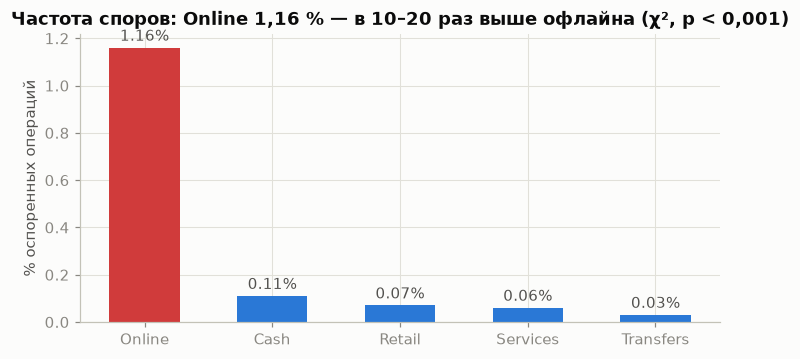

In [8]:
dis = q("""
SELECT mc.category_group,
       count(*) AS txns,
       count(*) FILTER (WHERE t.is_disputed) AS disputed,
       round(100.0*count(*) FILTER (WHERE t.is_disputed)/count(*), 2) AS disputed_pct,
       round(sum(t.amount_uzs) FILTER (WHERE t.is_disputed)/1e6, 1) AS disputed_mln
FROM ds_transactions_2 t
JOIN ds_merchants_2 m USING(merchant_id)
JOIN ds_mcc_categories mc ON mc.mcc_code = m.mcc_code
GROUP BY 1 ORDER BY disputed_pct DESC
""")
obs = np.array([dis["disputed"], dis["txns"] - dis["disputed"]]).T
chi2, p_chi, dof, _ = stats.chi2_contingency(obs)
share = 100*dis.loc[dis.category_group=="Online","disputed_mln"].iloc[0]/dis["disputed_mln"].sum()
print(dis.to_string(index=False))
print(f"\nχ² = {chi2:.0f}, df = {dof}, p = {p_chi:.1e}; Online держит {share:.0f}% спорных сумм")

fig, ax = plt.subplots(figsize=(7.5, 3.4))
colors = [CRITICAL if g == "Online" else BLUE for g in dis["category_group"]]
ax.bar(dis["category_group"], dis["disputed_pct"], width=0.55, color=colors)
for i, r_ in dis.iterrows():
    ax.text(i, r_["disputed_pct"]+0.03, f"{r_.disputed_pct}%", ha="center", fontsize=10, color=INK2)
ax.set_title("Частота споров: Online 1,16 % — в 10–20 раз выше офлайна (χ², p < 0,001)")
ax.set_ylabel("% оспоренных операций")
save(fig, "a3_dispute_rate"); plt.show()

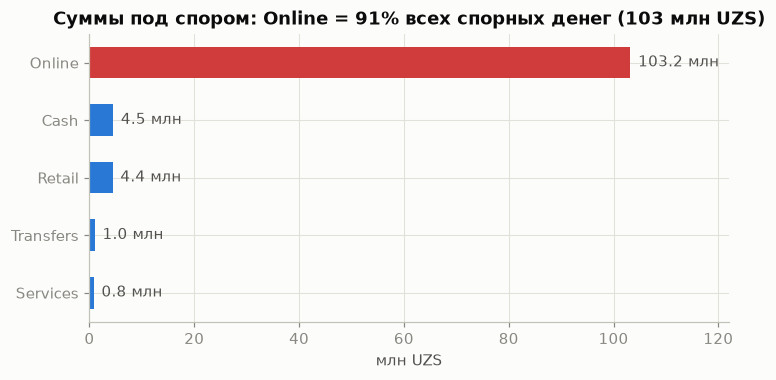

In [9]:
fig, ax = plt.subplots(figsize=(7.5, 3.4))
d2 = dis.sort_values("disputed_mln")
colors = [CRITICAL if g == "Online" else BLUE for g in d2["category_group"]]
ax.barh(d2["category_group"], d2["disputed_mln"], color=colors, height=0.55)
for yv, v in enumerate(d2["disputed_mln"]):
    ax.text(v+1.5, yv, f"{v:.1f} млн", va="center", fontsize=9.5, color=INK2)
ax.set_title(f"Суммы под спором: Online = {share:.0f}% всех спорных денег (103 млн UZS)")
ax.set_xlabel("млн UZS"); ax.set_xlim(0, 122)
save(fig, "a3_dispute_money"); plt.show()

**Вывод A3.** Online — аномальная зона споров: **1,16 %** операций оспаривается против
0,03–0,11 % в остальных группах (χ² = 400, p < 0,001). В деньгах концентрация ещё выше:
**103 из 114 млн UZS (91 %)** спорных сумм — онлайн. Средний спорный чек онлайна
(614 тыс UZS) втрое выше среднего чека операции. Рекомендация: обязательный 3-D Secure для
операций > 200 тыс UZS, антифрод-скоринг e-com мерчантов, мониторинг доли споров
по мерчанту (порог 1 %).

---

## Итог трека A

1. **Рост здоровый:** ×16 за год — ramp-up портфеля, декабрь +63 % — сезон; качество
   авторизации стабильно (отказы 5,5–6,9 %).
2. **Потеря №1 — студенты:** 11,2 % отказов (вдвое выше нормы, p < 0,001), причина
   продуктовая (лимиты/балансы) → микроовердрафт, уведомления, смарт-ретраи.
3. **Потеря №2 — онлайн-споры:** 1,16 % операций, 91 % спорных сумм (103 млн UZS)
   → 3-DS, скоринг e-com мерчантов, порог-мониторинг.

### Xulosa (UZ)
1. O'sish sog'lom: yiliga ×16 — karta portfeli ramp-up, dekabr +63 % — mavsum.
2. Yo'qotish №1 — studentlar: operatsiyalarning 11,2 % i rad etiladi (normadan 2×,
   p < 0,001), sabab mahsulotda (limit/balans) → mikro-overdraft, bildirishnoma, retray.
3. Yo'qotish №2 — onlayn nizolar: operatsiyalarning 1,16 % i, nizoli summalarning 90 % i
   (103 mln so'm, nizoli summalarning 91 %) → 3-D Secure, e-com skoring, monitoring.

### Соответствие требованиям
JOIN (3–4 таблицы) · GROUP BY · CTE (`WITH monthly`) · оконная `LAG` ·
графики: 2+2+2 · статистика: тренд+95 % ДИ (A1), z-тест долей (A2), χ² (A3) · без ML.